# Bayesian linear mixture model

In [1]:
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
import os 
import arviz as az
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = gpd.read_file('updated_data.geojson')
# selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman"]

# print(len(selected_covariates))

X=df[selected_covariates].to_numpy()
y=df["fem_empl_rate"].to_numpy()


Normalization and logit

In [3]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y = y/100
y_scaled = np.log(y/(1-y)) 



Stan Model

In [4]:
str_model="""
data {
    // Data
    int N;
    int P;

    int K; //nb of clusters

    matrix[N, P] X;
    array[N] real y;

    
    // Prior parameters
    array[4] real p0_params;
    real ai_dir; //in our model alpha=1 for dirichlet prior
}

transformed data {
    real a0 = p0_params[1];
    real b0 = p0_params[2];
    real sigma0 = p0_params[3];
    real sigma1 = p0_params[4];
}

parameters {
    array[K] real alpha;
    matrix[K,P] beta; 
    array[K] real<lower=0.00001> sigma;
    simplex[K] weights;

}

transformed parameters {
    matrix[N,K] mu;
    for(i in 1:N) {
        for(k in 1:K) {

            mu[i,k] = dot_product(row(X, i), beta[k]) + alpha[k];
        }
        
    }
}


model {

    vector[K] contributions;
    for (i in 1:N) {
        for(k in 1:K) {
            contributions[k] = log(weights[k]) + normal_lpdf(y[i] | mu[i,k], sigma[k]);
            // y[i] ~ normal(mu[i], sigma);  

            }
            target += log_sum_exp(contributions);
        }

        
    
    weights ~ dirichlet(rep_vector(ai_dir, K));

    for(k in 1:K) {
        alpha[k] ~ normal(0, a0);

        for (j in 1:P) {
            beta[k,j] ~ normal(0, b0);
        }
        
        //sigma[k] ~ inv_gamma(sigma0, sigma1);
        //sigma[k] ~ normal(0, 1);
        sigma[k] ~ cauchy(0, 1);
    }
}

generated quantities {
    array[N] int cluster_allocs;
    for(i in 1:N){
        vector[K] log_probs = log(weights);
        for(k in 1:K) {
            log_probs[k] += normal_lpdf(y[i] | mu[i,k], sigma[k]);
        }
        cluster_allocs[i] = categorical_rng(softmax(log_probs))-1;
    }
}

"""


if not os.path.exists("./stan"):
    os.mkdir("./stan")
stan_file = "./stan/linear_model.stan"
with open(stan_file, "w") as f:
    print(str_model, file=f)

# Compile stan model
linear_model = CmdStanModel(stan_file=stan_file)

16:31:14 - cmdstanpy - INFO - compiling stan file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model.stan to exe file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model
16:31:31 - cmdstanpy - INFO - compiled model executable: /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model


In [5]:
K=2
N=len(y_scaled)
P=X.shape[1]
gmm_data = {
    "N": N,
    "P":P,
    "K":K,

    "X":X_scaled,
    "y": y_scaled,

    "p0_params": np.array([0.2, 0.2, 3, 2]),
    "ai_dir":5
}

# Algorithm parameters
algo_params = {
    "n_chains": 6,
    "n_burnin": 1000,
    "n_iter": 2000
}

# Sample
model = linear_model.sample(data=gmm_data, chains=algo_params["n_chains"], parallel_chains=algo_params["n_chains"],
                                  iter_warmup=algo_params["n_burnin"], iter_sampling=algo_params["n_iter"])

# Convert to arviz data type
chains = az.from_cmdstanpy(model)

16:31:32 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]
















chain 1:   3%|▎         | 100/3000 [00:00<00:14, 195.14it/s, (Warmup)]









chain 1:   7%|▋         | 200/3000 [00:00<00:11, 243.56it/s, (Warmup)]






chain 1:  10%|█         | 300/3000 [00:01<00:09, 296.00it/s, (Warmup)]







chain 1:  13%|█▎        | 400/3000 [00:01<00:07, 336.61it/s, (Warmup)]















chain 1:  17%|█▋        | 500/3000 [00:01<00:07, 329.50it/s, (Warmup)]









chain 1:  20%|██        | 600/3000 [00:01<00:06, 363.78it/s, (Warmup)]









chain 1:  23%|██▎       | 700/3000 [00:02<00:05, 410.30it/s, (Warmup)]









chain 1:  27%|██▋       | 800/3000 [00:02<00:05, 428.45it/s, (Warmup)]







chain 1:  30%|███       | 900/3000 [00:02<00:04, 453.97it/s, (Warmup)]













chain 1:  33%|███▎      | 1000/3000 [00:02<00:04, 414.08it/s, (Sampling)]














chain 1:  37%|███▋      | 1100/3000 [00:03<00:04, 388.73it


16:31:41 - cmdstanpy - INFO - CmdStan done processing.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (24), generating only 20 plots
  warnings.warn(


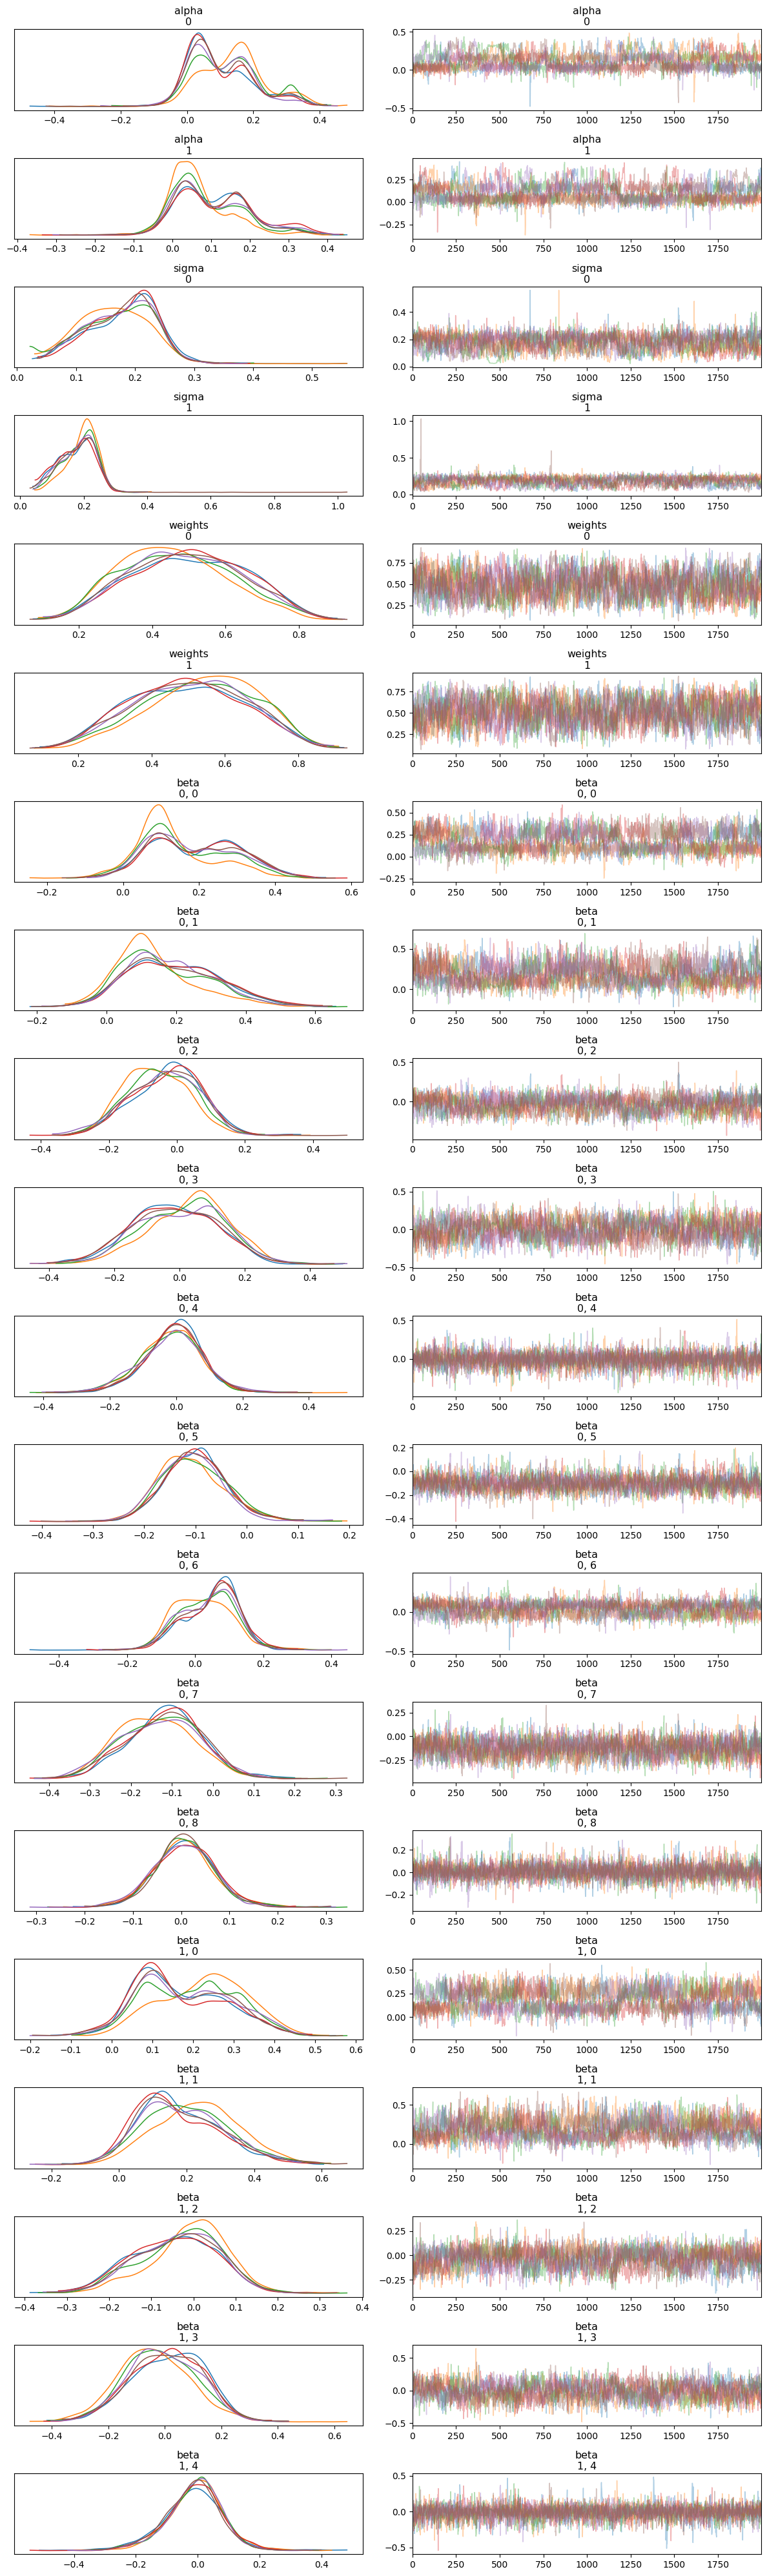

In [6]:
az.plot_trace(chains, var_names=["alpha","sigma","weights","beta"], compact=False)
plt.tight_layout()
plt.show()

## Visualization of the predictive density given x_i (part not rigorous)

In [7]:
# Y1_dis=Y1-(beta1*X1+alpha1)
# Y2_dis=Y2-(beta2*X2+alpha2)
# Y3_dis=Y3-(beta3*X3+alpha3)

# plt.hist(Y1_dis,bins=20)
# plt.show()
# plt.hist(Y2_dis,bins=20)
# plt.show()
# plt.hist(Y3_dis,bins=20)
# plt.show()

In [8]:
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

# def predictive_gaussian_mix_uni(chains, x_grid,ind_instance):
#     # Extract chains
#     weights = np.vstack(chains.posterior.weights)
#     # print(weights.shape)
#     mu = np.vstack(chains.posterior.mu)
#     print("mu.shape",mu.shape)
#     sigma = np.vstack(chains.posterior.sigma)
#     num_components = weights.shape[1]
#     # Create buffer and fill
#     out = np.zeros(shape=(weights.shape[0], len(x_grid)))
#     for j in range(out.shape[0]):
#         eval_dens = np.zeros_like(x_grid)
#         for k in range(num_components):
#             eval_dens += weights[j,k] * tfd.Normal(mu[j,ind_instance,k], sigma[j,k]).prob(x_grid)
#         out[j,:] = eval_dens
#     # Copmute mean
#     return np.mean(out, axis=0)

def predictive_gaussian_mix_uni(chains, x_grid,ind_instance,cluster_k):
    # Extract chains
    print(chains.posterior.weights.shape)
    weights = np.vstack(chains.posterior.weights)
    print(weights.shape)
    mu = np.vstack(chains.posterior.mu)
    print("mu.shape",mu.shape)
    sigma = np.vstack(chains.posterior.sigma)
    num_components = weights.shape[1]
    # Create buffer and fill
    out = np.zeros(shape=(weights.shape[0], len(x_grid)))
    for j in range(out.shape[0]):
        eval_dens = np.zeros_like(x_grid)
        # for k in range(num_components):
        eval_dens += tfd.Normal(mu[j,ind_instance,cluster_k], sigma[j,cluster_k]).prob(x_grid)
        out[j,:] = eval_dens
    # Copmute mean
    return np.mean(out, axis=0)

# x = np.linspace(0, 40, 1000)
# # x = np.linspace(0, 40, 1000)

# # Compute posterior mean density
# ind_instance=15
# post_dens = predictive_gaussian_mix_uni(chains, x, ind_instance,cluster_k=1)
# # Plot posterior mean density

# plt.hist(Y1_dis+(beta1*X[ind_instance]+alpha1), density=True, alpha = 0.5, bins = 30)
# # plt.hist(Y2_dis+(beta2*X[ind_instance]+alpha2), density=True, alpha = 0.5, bins = 30)
# plt.plot(x, post_dens, linewidth=3)

# plt.show()


## In this part, we want to assign y_i to a cluster (0,1,2)

In [9]:
# Function that computes the posterior similarity matrix
def get_psm(clus_alloc_chain):
    c_chain = np.vstack(clus_alloc_chain)
    out = np.zeros((c_chain.shape[1], c_chain.shape[1]))
    for i in range(c_chain.shape[1]):
        for j in range(i):
            out[i, j] = np.mean(c_chain[:, i] == c_chain[:, j])
    return out + out.T + np.eye(out.shape[0])



In [10]:
# Function that computes the cluster estimate that minimizes the binder loss function
def minbinder_sample(clus_alloc_chain, psm):
    losses = np.zeros(len(clus_alloc_chain))
    c_chain = np.vstack(clus_alloc_chain)
    for i in range(c_chain.shape[1]):
        for j in range(i):
            losses += (np.mean(c_chain[:, i] == c_chain[:, j]) - psm[i, j]) ** 2
    best_iter = np.argmin(losses)
    return clus_alloc_chain[best_iter]

In [11]:
print(chains.posterior.cluster_allocs.shape)

(6, 2000, 107)


In [12]:
# Retrieve cluster allocation variables
clust_allocs_chain = np.vstack(chains.posterior.cluster_allocs)

In [13]:
# Compute posterior similarity matrix
psm = get_psm(clust_allocs_chain)

In [14]:
# Compute point estimate of the cluster
best_clus = minbinder_sample(clust_allocs_chain, psm)

## In this part, we want to derive the coefficients alpha and beta for each cluster.

In [15]:
# print(model.summary()[:20])

# alphas_recovered=model.summary().iloc[1:4,0].values
# betas_recovered=model.summary().iloc[4:7,0].values



In [16]:
# from scipy.stats import gaussian_kde

# def posterior_mode(samples, n_grid=2000):
#     kde = gaussian_kde(samples)
#     x = np.linspace(samples.min(), samples.max(), n_grid)
#     return x[np.argmax(kde(x))]



# alpha=np.vstack(chains.posterior.alpha)
# print(alpha.shape)

# alpha_modes = {}
# for i in range(alpha.shape[1]):
#     alpha_modes[f"alpha[{i+1}]"] = posterior_mode(alpha[:, i])

# alpha_modes

In [17]:
# from scipy.optimize import linear_sum_assignment


# aligned_beta = []
# aligned_alpha = []


# beta_chain=np.vstack(chains.posterior.beta)
# alpha_chain=np.vstack(chains.posterior.alpha)
# print(beta_chain.shape)
# print(clust_allocs_chain.shape)

# for t in range(clust_allocs_chain.shape[0]):
#     zt = clust_allocs_chain[t]

#     # cost matrix
#     cost = np.zeros((K,K))
#     for k in range(K):
#         for h in range(K):
#             cost[k,h] = np.sum((zt == k) & (best_clus != h))

#     row_ind, col_ind = linear_sum_assignment(cost)

#     beta_t = beta_chain[t][row_ind]
#     alpha_t = alpha_chain[t][row_ind]

#     aligned_beta.append(beta_t)
#     aligned_alpha.append(alpha_t)


# beta_retrieved=np.mean(aligned_beta, axis=0)[:,0]
# alpha_retrieved=np.mean(aligned_alpha, axis=0)

# print("beta_retrieved",beta_retrieved)

# print("alpha_retrieved",alpha_retrieved)


## Visualization of the results

[1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0.
 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1.
 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1.
 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1.]


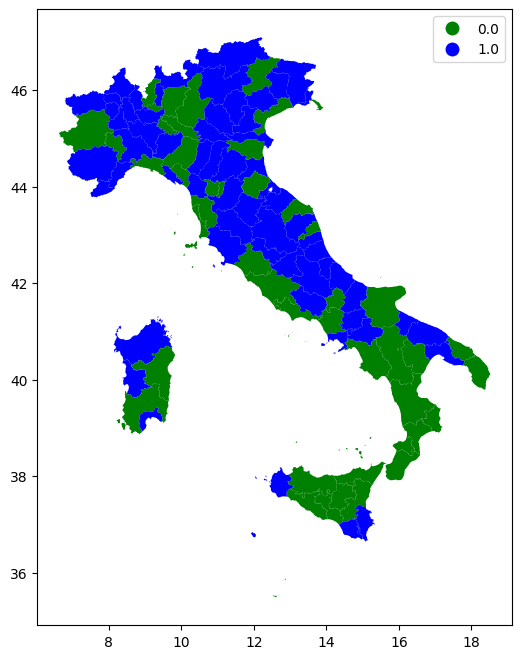

In [20]:
from matplotlib.colors import ListedColormap

# Plot the point cluster estimate on the empirical density histogram
# plt.hist(data, density=True, alpha=0.3)


color_map = {
    0: "red",      # couleur1
    1: "blue",     # couleur2
    2: "green"     # etc.
}

print(best_clus)

df["cluster_bayes"] = best_clus


# df.plot(column="cluster_bayes", categorical=True, legend=True)
# cmap = ListedColormap(["blue", "red","green"])
cmap = ListedColormap(["green", "red","blue"])

ax = df.plot(
    column="cluster_bayes",
    categorical=True,
    cmap=cmap,
    legend=True,
    figsize=(8, 8)
)

plt.show()



In [19]:
print("model.summary",model.summary()[:20])


model.summary                 Mean      MCSE    StdDev       MAD         5%        50%  \
lp__      -10.597600  0.128883  5.045640  4.888660 -19.744500 -10.101000   
alpha[1]    0.112206  0.010665  0.101837  0.103734  -0.021929   0.098908   
alpha[2]    0.097427  0.009707  0.094805  0.093630  -0.023900   0.075814   
beta[1,1]   0.174072  0.013437  0.116352  0.125940   0.009494   0.151317   
beta[1,2]   0.179285  0.013568  0.130108  0.132517  -0.004235   0.159515   
beta[1,3]  -0.040692  0.008118  0.100831  0.107266  -0.206195  -0.037084   
beta[1,4]   0.000219  0.010742  0.130547  0.137833  -0.214444   0.004622   
beta[1,5]  -0.012892  0.002245  0.093252  0.084527  -0.173827  -0.007528   
beta[1,6]  -0.102985  0.002352  0.062625  0.060379  -0.199665  -0.105070   
beta[1,7]   0.039710  0.006146  0.083090  0.085654  -0.096182   0.049012   
beta[1,8]  -0.124869  0.004867  0.093591  0.096198  -0.278991  -0.120816   
beta[1,9]   0.007099  0.001498  0.063798  0.059081  -0.094434   0.006355  